In [1]:
import pandas as pd
from pathlib import Path
from typing import Dict, List

In [24]:
import pandas as pd

def mark_cluster_members(cluster_members_path, validated_db_path):
    # Загружаем данные
    cm = pd.read_csv(cluster_members_path, sep="\t")
    vdb = pd.read_csv(validated_db_path)
    vdb = vdb[vdb.padj.notna()]

    # Приводим cluster_members
    cm_subset = cm[['gene', 'cdr3aa', 'antigen.epitope']].dropna()
    cm_subset = cm_subset.rename(columns={'gene': 'chain', 
                                          'cdr3aa': 'cdr3', 
                                          'antigen.epitope': 'epitope_aa'})
    cm_subset['chain'] = cm_subset['chain'].str.upper().str.strip()
    cm_subset['cdr3'] = cm_subset['cdr3'].astype(str).str.strip()
    cm_subset['epitope_aa'] = cm_subset['epitope_aa'].astype(str).str.strip()

    cluster_set = set(map(tuple, cm_subset[['chain', 'cdr3', 'epitope_aa']]
                          .itertuples(index=False, name=None)))

    # Добавляем флаги к vdb
    vdb = vdb.copy()
    vdb['in_cluster_alpha'] = vdb.apply(
        lambda row: (('TRA', str(row['cdr3_alpha_aa']).strip(), str(row['epitope_aa']).strip()) in cluster_set)
        if pd.notna(row['cdr3_alpha_aa']) and pd.notna(row['epitope_aa']) else False,
        axis=1
    )
    vdb['in_cluster_beta'] = vdb.apply(
        lambda row: (('TRB', str(row['cdr3_beta_aa']).strip(), str(row['epitope_aa']).strip()) in cluster_set)
        if pd.notna(row['cdr3_beta_aa']) and pd.notna(row['epitope_aa']) else False,
        axis=1
    )
    vdb['in_cluster_any'] = vdb['in_cluster_alpha'] | vdb['in_cluster_beta']

    return vdb

# Пример:
# vdb_marked = mark_cluster_members("cluster_members.txt", "01_05_2025_TCRvdb.csv")
# display(vdb_marked[['cdr3_alpha_aa','cdr3_beta_aa','epitope_aa','in_cluster_alpha','in_cluster_beta','in_cluster_any']].head())


In [25]:
paths = mark_cluster_members("cluster_members.txt", "01_05_2025_TCRvdb.csv")


In [26]:
paths

,Unnamed: 0,name,clonotype_aa,cdr3_alpha_aa,cdr3_beta_aa,TRAV,TRAJ,TRBV,TRBJ,TRBD,...,vdjdb_score,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,in_cluster_alpha,in_cluster_beta,in_cluster_any
0,0,1_5_H3_86_YLQPRTFLL,TRAV12-1_CVVNIDTDKLIF_TRAJ34--TRBV2_CATGGDHNTG...,CVVNIDTDKLIF,CATGGDHNTGELFF,TRAV12-1,TRAJ34,TRBV2,TRBJ2-2,NaN,...,0.0,198.217526,-2.653196,0.188261,-13.561965,6.730858e-42,1.636410e-40,True,False,True
1,1,1_6_G24_179_YLQPRTFLL,TRAV5_CAEILDFGNEKLTF_TRAJ48--TRBV20-1_CSARDPSG...,CAEILDFGNEKLTF,CSARDPSGVKLFF,TRAV5,TRAJ48,TRBV20-1,TRBJ1-4,NaN,...,1.0,48.227439,-1.112206,0.302166,-3.349832,8.086058e-04,5.774793e-03,False,False,False
2,2,1_6_H1_84_YLQPRTFLL,TRAV35_CAAMNYGGSQGNLIF_TRAJ42--TRBV6-2_CASSYRG...,CAAMNYGGSQGNLIF,CASSYRGTGLNEQFF,TRAV35,TRAJ42,TRBV6-2,TRBJ2-1,NaN,...,0.0,77.593373,0.206727,0.238408,0.447668,6.543928e-01,1.000000e+00,False,False,False
3,3,1_6_H2_85_YLQPRTFLL,TRAV21_CAVKDTDKLIF_TRAJ34--TRBV7-8_CASSLAGSSYN...,CAVKDTDKLIF,CASSLAGSSYNSPLHF,TRAV21,TRAJ34,TRBV7-8,TRBJ1-6,NaN,...,0.0,21.861277,1.116579,0.451138,2.253366,2.423609e-02,1.296120e-01,False,False,False
4,4,1_6_H3_86_YLQPRTFLL,TRAV12-1_CVVNRNNDMRF_TRAJ43--TRBV2_CATQSDPNTGE...,CVVNRNNDMRF,CATQSDPNTGELFF,TRAV12-1,TRAJ43,TRBV2,TRBJ2-2,NaN,...,0.0,251.554645,-2.851169,0.172124,-15.983631,1.661776e-57,6.701844e-56,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,631,2_16_E5_52_GLCTLVAML,TRAV13-1_CAVYGQNFVF_TRAJ26--TRBV20-1_CSARDGTGN...,CAVYGQNFVF,CSARDGTGNGYTF,TRAV13-1,TRAJ26,TRBV20-1,TRBJ1-2,NaN,...,2.0,29.338977,0.700332,0.373308,1.608141,1.078043e-01,4.228298e-01,False,True,True
632,632,2_16_E4_51_GLCTLVAML,TRAV5_CAEYSSASKIIF_TRAJ3--TRBV14_CASSQSPGGTQYF...,CAEYSSASKIIF,CASSQSPGGTQYF,TRAV5,TRAJ3,TRBV14,TRBJ2-3,NaN,...,2.0,353.175071,3.024750,0.146498,19.964393,1.123850e-88,1.481753e-86,False,True,True
633,633,2_15_E15_146_GLCTLVAML,TRAV5_CAVPAEGGYNKLIF_TRAJ4--TRBV20-1_CSARDSTGN...,CAVPAEGGYNKLIF,CSARDSTGNGYTF,TRAV5*01,TRAJ4*01,TRBV20-1*01,TRBJ1-2*01,NaN,...,0.0,31.798505,0.642121,0.371530,1.459158,1.445216e-01,5.187643e-01,False,True,True
634,634,2_16_F6_65_GLCTLVAML,TRAV23S1_CAGNNARPMF_TRAJ3S2--TRBV16S1_CASSQSPG...,CAGNNARPMF,CASSQSPGGVAFF,TRAV23S1,TRAJ3S2,TRBV16S1,TRBJ1S1,NaN,...,0.0,47.721097,-0.152989,0.306176,-0.173067,8.625986e-01,1.000000e+00,False,True,True


In [27]:
paths['is_significant'] = paths.padj < 1e-5

In [28]:
paths

,Unnamed: 0,name,clonotype_aa,cdr3_alpha_aa,cdr3_beta_aa,TRAV,TRAJ,TRBV,TRBJ,TRBD,...,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,in_cluster_alpha,in_cluster_beta,in_cluster_any,is_significant
0,0,1_5_H3_86_YLQPRTFLL,TRAV12-1_CVVNIDTDKLIF_TRAJ34--TRBV2_CATGGDHNTG...,CVVNIDTDKLIF,CATGGDHNTGELFF,TRAV12-1,TRAJ34,TRBV2,TRBJ2-2,NaN,...,198.217526,-2.653196,0.188261,-13.561965,6.730858e-42,1.636410e-40,True,False,True,True
1,1,1_6_G24_179_YLQPRTFLL,TRAV5_CAEILDFGNEKLTF_TRAJ48--TRBV20-1_CSARDPSG...,CAEILDFGNEKLTF,CSARDPSGVKLFF,TRAV5,TRAJ48,TRBV20-1,TRBJ1-4,NaN,...,48.227439,-1.112206,0.302166,-3.349832,8.086058e-04,5.774793e-03,False,False,False,False
2,2,1_6_H1_84_YLQPRTFLL,TRAV35_CAAMNYGGSQGNLIF_TRAJ42--TRBV6-2_CASSYRG...,CAAMNYGGSQGNLIF,CASSYRGTGLNEQFF,TRAV35,TRAJ42,TRBV6-2,TRBJ2-1,NaN,...,77.593373,0.206727,0.238408,0.447668,6.543928e-01,1.000000e+00,False,False,False,False
3,3,1_6_H2_85_YLQPRTFLL,TRAV21_CAVKDTDKLIF_TRAJ34--TRBV7-8_CASSLAGSSYN...,CAVKDTDKLIF,CASSLAGSSYNSPLHF,TRAV21,TRAJ34,TRBV7-8,TRBJ1-6,NaN,...,21.861277,1.116579,0.451138,2.253366,2.423609e-02,1.296120e-01,False,False,False,False
4,4,1_6_H3_86_YLQPRTFLL,TRAV12-1_CVVNRNNDMRF_TRAJ43--TRBV2_CATQSDPNTGE...,CVVNRNNDMRF,CATQSDPNTGELFF,TRAV12-1,TRAJ43,TRBV2,TRBJ2-2,NaN,...,251.554645,-2.851169,0.172124,-15.983631,1.661776e-57,6.701844e-56,True,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,631,2_16_E5_52_GLCTLVAML,TRAV13-1_CAVYGQNFVF_TRAJ26--TRBV20-1_CSARDGTGN...,CAVYGQNFVF,CSARDGTGNGYTF,TRAV13-1,TRAJ26,TRBV20-1,TRBJ1-2,NaN,...,29.338977,0.700332,0.373308,1.608141,1.078043e-01,4.228298e-01,False,True,True,False
632,632,2_16_E4_51_GLCTLVAML,TRAV5_CAEYSSASKIIF_TRAJ3--TRBV14_CASSQSPGGTQYF...,CAEYSSASKIIF,CASSQSPGGTQYF,TRAV5,TRAJ3,TRBV14,TRBJ2-3,NaN,...,353.175071,3.024750,0.146498,19.964393,1.123850e-88,1.481753e-86,False,True,True,True
633,633,2_15_E15_146_GLCTLVAML,TRAV5_CAVPAEGGYNKLIF_TRAJ4--TRBV20-1_CSARDSTGN...,CAVPAEGGYNKLIF,CSARDSTGNGYTF,TRAV5*01,TRAJ4*01,TRBV20-1*01,TRBJ1-2*01,NaN,...,31.798505,0.642121,0.371530,1.459158,1.445216e-01,5.187643e-01,False,True,True,False
634,634,2_16_F6_65_GLCTLVAML,TRAV23S1_CAGNNARPMF_TRAJ3S2--TRBV16S1_CASSQSPG...,CAGNNARPMF,CASSQSPGGVAFF,TRAV23S1,TRAJ3S2,TRBV16S1,TRBJ1S1,NaN,...,47.721097,-0.152989,0.306176,-0.173067,8.625986e-01,1.000000e+00,False,True,True,False


In [16]:
df.columns

Index(['Unnamed: 0', 'name', 'clonotype_aa', 'cdr3_alpha_aa', 'cdr3_beta_aa',
       'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'TRBD', 'TRAV_IMGT', 'TRAJ_IMGT',
       'TRBV_IMGT', 'TRBD_IMGT', 'TRBJ_IMGT', 'epitope_aa', 'hla_short',
       'hla_long', 'data_origin', 'vdjdb_score', 'baseMean', 'log2FoldChange',
       'lfcSE', 'stat', 'pvalue', 'padj'],
      dtype='object')

In [15]:
df = df[df.padj.notna()]

In [18]:
df.epitope_aa.value_counts()

epitope_aa
YLQPRTFLL    421
GLCTLVAML    193
Name: count, dtype: int64

In [30]:
import pandas as pd

def confusion_from_flags(df, pred_col='in_cluster_any', true_col='is_significant'):
    # строим перекрестную таблицу
    conf = pd.crosstab(df[pred_col], df[true_col])
    conf.index = conf.index.map({True: 'Predicted YES', False: 'Predicted NO'})
    conf.columns = conf.columns.map({True: 'True YES', False: 'True NO'})
    return conf

# Пример:
conf_matrix = confusion_from_flags(paths)
display(conf_matrix)


is_significant,True NO,True YES
in_cluster_any,,
Predicted NO,223,71
Predicted YES,85,235


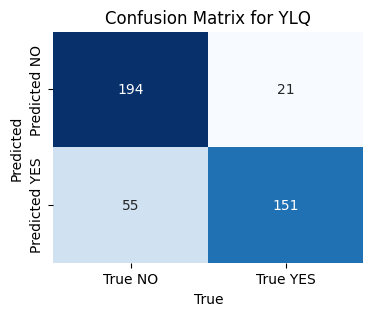

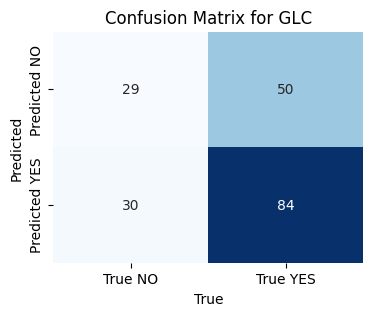

is_significant,True NO,True YES
in_cluster_any,,
Predicted NO,29,50
Predicted YES,30,84


In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_for_epitope(df, epitope, pred_col='in_cluster_any', true_col='is_significant'):
    sub = df[df['epitope_aa'].str.startswith(epitope)]
    conf = pd.crosstab(sub[pred_col], sub[true_col])
    conf.index = conf.index.map({True: 'Predicted YES', False: 'Predicted NO'})
    conf.columns = conf.columns.map({True: 'True YES', False: 'True NO'})

    plt.figure(figsize=(4,3))
    sns.heatmap(conf, annot=True, fmt='d', cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix for {epitope}")
    plt.ylabel("Predicted")
    plt.xlabel("True")
    plt.show()
    return conf

# Пример вызова:
plot_confusion_for_epitope(paths, "YLQ")
plot_confusion_for_epitope(paths, "GLC")


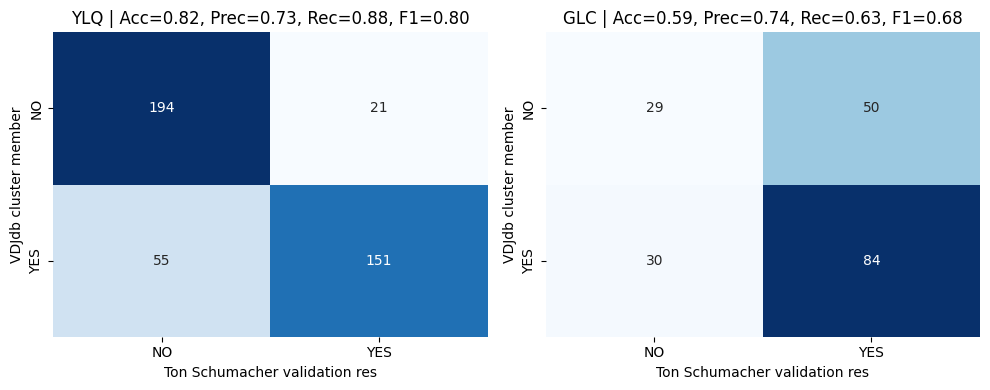

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_confusion_for_epitope(df, epitope, ax, pred_col='in_cluster_any', true_col='is_significant'):
    # фильтруем по эпитопу
    sub = df[df['epitope_aa'].str.startswith(epitope)]
    conf = pd.crosstab(sub[pred_col], sub[true_col])

    # гарантируем наличие всех ячеек
    for val in [True, False]:
        if val not in conf.index:
            conf.loc[val, :] = 0
        if val not in conf.columns:
            conf.loc[:, val] = 0
    conf = conf.sort_index().sort_index(axis=1)

    # метрики
    tp = conf.loc[True, True]
    fp = conf.loc[True, False]
    fn = conf.loc[False, True]
    tn = conf.loc[False, False]
    total = tp + fp + fn + tn

    accuracy = (tp + tn) / total if total > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    # подписи осей
    conf.index = conf.index.map({True: 'YES', False: 'NO'})
    conf.columns = conf.columns.map({True: 'YES', False: 'NO'})

    # рисуем
    sns.heatmap(conf, annot=True, fmt='d', cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"{epitope} | Acc={accuracy:.2f}, Prec={precision:.2f}, Rec={recall:.2f}, F1={f1:.2f}")
    ax.set_ylabel("VDJdb cluster member")
    ax.set_xlabel("Ton Schumacher validation res")

    return conf, {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

# Панель с двумя эпитопами
def plot_two_epitopes(df, epi1="YLQ", epi2="GLC"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    plot_confusion_for_epitope(df, epi1, ax=axes[0])
    plot_confusion_for_epitope(df, epi2, ax=axes[1])

    plt.tight_layout()
    plt.show()

# Пример:
plot_two_epitopes(paths, "YLQ", "GLC")
